# Evaluación 2

**Integrante 1:** Paz Valdes

**Integrante 2:** Maximiliano Matus

**Integrante 3:** Santiago Franichevic

**Correo Electrónico integrante 1:** paz.valdes2301@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** maximiliano.matus2301@alumnos.ubiobio.cl

**Correo Electrónico integrante 3:** santiago.franichevic2301@alumnos.ubiobio.cl

**Fecha de Creación:** Mayo de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 2 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

# Carga de datos

In [1]:
!wget https://github.com/DaFrokki/620454/blob/main/data/ingestion/retail_ventas.csv

--2026-05-27 07:12:45--  https://github.com/DaFrokki/620454/blob/main/data/ingestion/retail_ventas.csv
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘retail_ventas.csv.1’

retail_ventas.csv.1     [  <=>               ] 220.97K   621KB/s    in 0.4s    

2026-05-27 07:12:48 (621 KB/s) - ‘retail_ventas.csv.1’ saved [226274]



In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin


In [3]:
data = pd.read_csv('retail_ventas.csv')
data.head()

,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales
0,86,1445.454837,1,2.611389,0.925557,97.313562,41,0,376.608869,B,40377.989406
1,35,1973.195744,18,5.603718,1.526210,88.821903,52,0,197.329419,A,59430.330077
2,41,1727.496264,24,7.330847,1.297304,109.273193,15,0,262.737637,A,56547.323925
3,97,1284.634121,10,16.074751,0.862449,98.362477,45,0,392.171919,A,36408.752020
4,25,1457.596546,5,9.278104,1.264497,92.081812,45,0,411.085409,B,40500.513890


## Objetivo de predicción

Predecir las ventas semanales a partir de las características de una tienda

## Exploración inicial

En esta sección realizamos una exploración rápida del dataset para entender dimensiones, tipos de datos, estadísticas descriptivas, valores faltantes y distribución de categorías clave\. Esto nos ayuda a planificar la preparación y el modelamiento\.

In [41]:
df = data.copy()
print(df.shape)
df

(25500, 11)


,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales
0,86,1445.454837,1,2.611389,0.925557,97.313562,41,0,376.608869,B,40377.989406
1,35,1973.195744,18,5.603718,1.526210,88.821903,52,0,197.329419,A,59430.330077
2,41,1727.496264,24,7.330847,1.297304,109.273193,15,0,262.737637,A,56547.323925
3,97,1284.634121,10,16.074751,0.862449,98.362477,45,0,392.171919,A,36408.752020
4,25,1457.596546,5,9.278104,1.264497,92.081812,45,0,411.085409,B,40500.513890
...,...,...,...,...,...,...,...,...,...,...,...
25495,33,1588.184428,12,23.857674,1.458489,106.658549,6,0,516.268321,A,56266.453706
25496,35,1504.049012,7,21.914138,0.971635,102.182660,12,0,270.284543,A,36881.622381
25497,92,1179.994368,12,2.028806,1.675301,112.275126,9,1,238.560947,C,26398.054981
25498,19,1203.887481,7,26.237947,1.296958,102.257066,45,0,297.286257,C,25052.853654


## Revisión de nulos

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_tienda           25500 non-null  int64  
 1   tamano_tienda       25500 non-null  float64
 2   antiguedad_tienda   25500 non-null  int64  
 3   temperatura         24224 non-null  float64
 4   precio_combustible  24221 non-null  float64
 5   indice_economico    25500 non-null  float64
 6   semana              25500 non-null  int64  
 7   es_feriado          25500 non-null  int64  
 8   clientes_estimados  24220 non-null  float64
 9   tipo_tienda         25500 non-null  object 
 10  ventas_semanales    25500 non-null  float64
dtypes: float64(6), int64(4), object(1)
memory usage: 2.1+ MB


## Revisión de atípicos

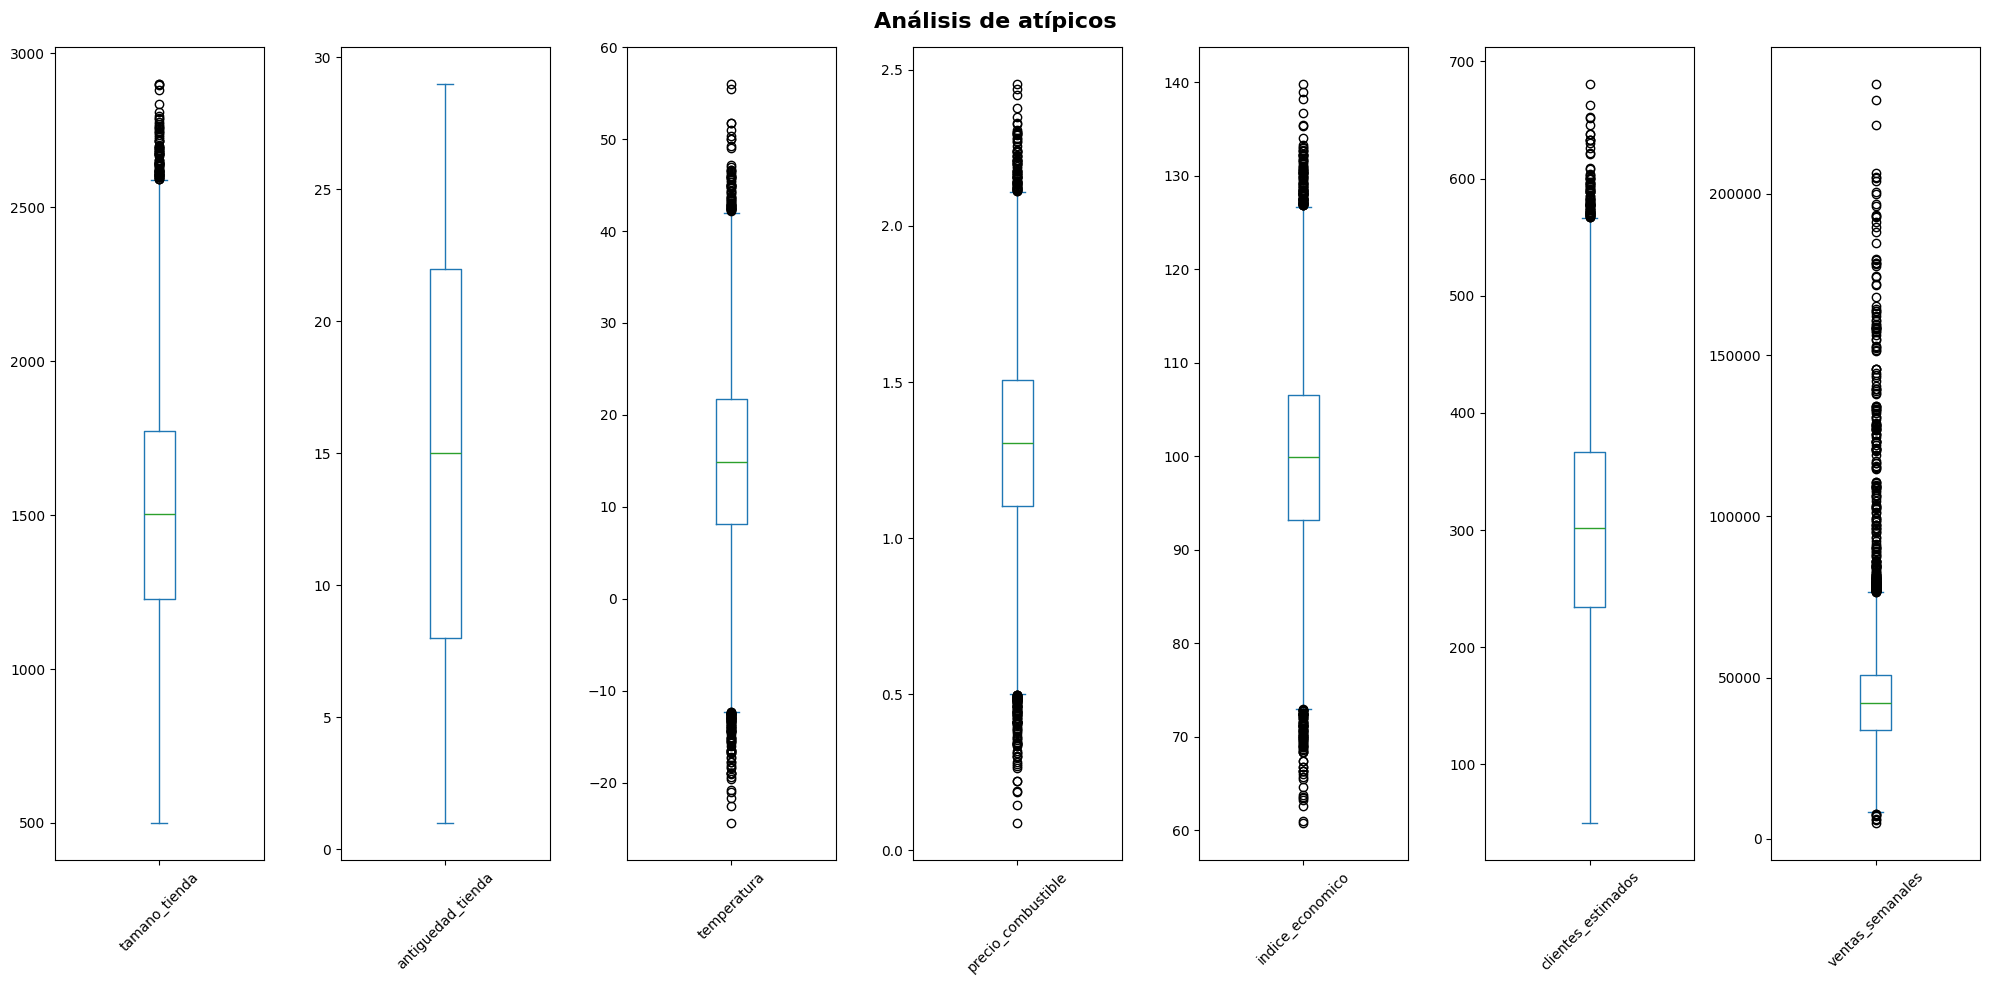

In [6]:
# Revisión de atipicos en variables cuantitativas
revision_atipicos = ['tamano_tienda', 'antiguedad_tienda', 'temperatura', 'precio_combustible', 'indice_economico',
    'clientes_estimados', 'ventas_semanales'
]
# Codigo para realizar los boxplots con las variables

fig, axes = plt.subplots(1, 7, figsize=(20,20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(20,10), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

## Revisión de inconsistencias

In [7]:
# Revisión de inconsistencias Cuantitativas

inconsistentes = data[(data["ventas_semanales"] <= 0) | (data["tamano_tienda"] < 0) | (data["clientes_estimados"] < 0) | (data["antiguedad_tienda"] < 0)]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales


In [8]:
# Inconsistencias cualitativas
data['tipo_tienda'].unique()

array(['B', 'A', 'C'], dtype=object)

In [9]:
# Muestra los datos cuantitativos
data.drop(columns=['tipo_tienda']).describe()

,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,ventas_semanales
count,25500.00000,25500.000000,25500.000000,24224.000000,24221.000000,25500.000000,25500.000000,25500.000000,24220.000000,25500.000000
mean,50.81749,1501.338719,15.092824,14.954302,1.303299,99.889523,26.376078,0.098510,300.649372,43108.586339
std,28.93800,399.711835,8.365652,9.999174,0.299869,9.961593,14.996831,0.298009,98.822402,14538.319334
min,1.00000,500.000000,1.000000,-24.344608,0.086903,60.799835,1.000000,0.000000,50.000000,4905.208771
25%,26.00000,1229.224069,8.000000,8.124612,1.102983,93.140607,13.000000,0.000000,234.014040,33827.197346
50%,51.00000,1503.366822,15.000000,14.930043,1.303386,99.917526,26.000000,0.000000,301.600830,42117.538361
75%,76.00000,1773.575577,22.000000,21.735814,1.505762,106.582946,39.000000,0.000000,366.981593,50947.405475
max,100.00000,2901.612393,29.000000,56.005247,2.455792,139.836638,52.000000,1.000000,680.907511,234175.036973


In [10]:
# Muestra los datos cualitativos
data.describe(include = "object")

,tipo_tienda
count,25500
unique,3
top,A
freq,12708


In [11]:
columnas_con_nulos = data.isna().sum()[data.isna().sum() > 0]
resultado = pd.DataFrame({
    "Cantidad Nulos": columnas_con_nulos
    }).round(2)

resultado

,Cantidad Nulos
temperatura,1276
precio_combustible,1279
clientes_estimados,1280


In [12]:
# Obtener las columnas con valores nulos y tipo de objeto para analizar los valores atípicos para tratar los nulos
columnas_con_nulos = np.array(resultado.index)
columnas_con_nulos    

array(['temperatura', 'precio_combustible', 'clientes_estimados'],
      dtype=object)

## Cantidad de duplicados

In [13]:
# Muestra la cantidad de datos duplicados
data.duplicated().sum()

494

In [14]:
#vemos si estan duplicados por el id y semana (analiza toda la fila)
data[data.duplicated(keep=False)].sort_values(by=['id_tienda', 'semana'])


,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales
852,1,1662.308696,4,8.021267,1.358711,100.793627,1,0,208.593492,B,50334.268750
25472,1,1662.308696,4,8.021267,1.358711,100.793627,1,0,208.593492,B,50334.268750
1863,1,1775.899028,8,5.290492,1.161663,83.668164,16,0,NaN,B,34000.945523
25223,1,1775.899028,8,5.290492,1.161663,83.668164,16,0,NaN,B,34000.945523
1886,1,2034.754785,10,14.208497,0.938566,89.582706,17,0,291.469835,C,43551.521560
...,...,...,...,...,...,...,...,...,...,...,...
25425,100,1791.584326,21,31.701831,1.451529,95.250365,9,0,406.231342,C,47408.979071
5088,100,611.630993,17,23.214253,0.962835,80.465318,21,0,351.873700,A,27753.376425
25435,100,611.630993,17,23.214253,0.962835,80.465318,21,0,351.873700,A,27753.376425
21647,100,947.956801,21,7.726670,1.679441,108.104389,52,0,349.960333,C,23249.111970


In [15]:
if 'tipo_tienda' in df.columns:
    print(df['tipo_tienda'].value_counts())
else:
    print('Columna tipo_tienda no existe')

tipo_tienda
A    12708
B     7614
C     5178
Name: count, dtype: int64


## Selección de variables

In [16]:
# Se define variable objetivo
target = 'ventas_semanales'
features = [c for c in df.columns if c != target and c not in ['id_tienda']]
X = df[features]
y = df[target]

X.shape, y.shape, features

((25500, 9),
 (25500,),
 ['tamano_tienda',
  'antiguedad_tienda',
  'temperatura',
  'precio_combustible',
  'indice_economico',
  'semana',
  'es_feriado',
  'clientes_estimados',
  'tipo_tienda'])

In [17]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)
     


In [18]:
def tratar_duplicados(X : pd.DataFrame):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Set de datos.

  Retorno
  -------
  Nuevo set de datos SIN los duplicados

  """
  return X.drop_duplicates()

In [20]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

In [21]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
  """
  Convierte un array en un DataFrame

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  feature_names_ : array-like
    Nombres de las columnas.
  Returns
  -------
  DataFrame
    Conjunto de datos con nombres de columnas.
  """
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)
     


# Evaluación de variables predictoras

In [22]:
# Calcula la matriz de correlaciones
correlaciones = df.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

ventas_semanales      1.000000
tamano_tienda         0.593410
clientes_estimados    0.111599
es_feriado            0.107034
indice_economico      0.042103
id_tienda             0.005966
precio_combustible    0.001026
temperatura          -0.000746
antiguedad_tienda    -0.000979
semana               -0.010844
Name: ventas_semanales, dtype: float64

In [23]:
df.groupby("tipo_tienda")[target].mean().sort_values()

tipo_tienda
C    32657.412613
B    40586.519400
A    48878.116968
Name: ventas_semanales, dtype: float64

In [24]:
# Ver las correlaciones pero agregando las variables cualitativas, unas vez transformadas con el OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
tienda_encoded = encoder.fit_transform(df[["tipo_tienda"]])

data_ohe = pd.DataFrame(tienda_encoded, columns=encoder.get_feature_names_out())

data_corr = pd.concat([data, data_ohe], axis=1)

data_corr.corr(numeric_only=True)[target]

id_tienda             0.005966
tamano_tienda         0.593410
antiguedad_tienda    -0.000979
temperatura          -0.000746
precio_combustible    0.001026
indice_economico      0.042103
semana               -0.010844
es_feriado            0.107034
clientes_estimados    0.111599
ventas_semanales      1.000000
tipo_tienda_A         0.395553
tipo_tienda_B        -0.113188
tipo_tienda_C        -0.362875
Name: ventas_semanales, dtype: float64

### Definir tipos de variables

In [25]:
num_cols = ["tamano_tienda", "antiguedad_tienda", "temperatura", "precio_combustible","indice_economico","semana","es_feriado","clientes_estimados"]
cat_cols = ["tipo_tienda"]
print('Numéricas:', num_cols)
print('Categóricas:', cat_cols)

Numéricas: ['tamano_tienda', 'antiguedad_tienda', 'temperatura', 'precio_combustible', 'indice_economico', 'semana', 'es_feriado', 'clientes_estimados']
Categóricas: ['tipo_tienda']


## Se definen los Pipelines

In [26]:
# Preprocesamiento numérico: imputación con mediana
numeric_preprocess = Pipeline(steps=[
    ('winsorizer',Winsorizer()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Preprocesamiento categórico: imputación + one-hot encoding
categorical_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop="first",handle_unknown='ignore'))
])
#One hot encoding, transforma todo a codigo para que lo pueda leer mas facilmente la maquina
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_preprocess, num_cols),
        ('cat', categorical_preprocess, cat_cols)
    ],
    remainder="passthrough",
)

pipeline_limpieza_transformacion = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(tratar_duplicados)),
        ("preprocesamiento", preprocess)
    ]
)

preprocess

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('winsorizer', Winsorizer()),
                                                 ('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tamano_tienda', 'antiguedad_tienda',
                                  'temperatura', 'precio_combustible',
                                  'indice_economico', 'semana', 'es_feriado',
                                  'clientes_estimados']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['tipo_tienda'])])

## Transformación, limpieza y guardado de datos

In [27]:
df_clean = pipeline_limpieza_transformacion.fit_transform(df)
data_clean = pd.DataFrame(
    df_clean,
    columns=pipeline_limpieza_transformacion.named_steps["preprocesamiento"].get_feature_names_out()
)
data_clean.to_csv('retail_ventas_clean.csv', index=False)
print('datos limpios guardados como retail_ventas_clean.csv')

datos limpios guardados como retail_ventas_clean.csv


In [28]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25006 entries, 0 to 25005
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   num__tamano_tienda           25006 non-null  float64
 1   num__antiguedad_tienda       25006 non-null  float64
 2   num__temperatura             25006 non-null  float64
 3   num__precio_combustible      25006 non-null  float64
 4   num__indice_economico        25006 non-null  float64
 5   num__semana                  25006 non-null  float64
 6   num__es_feriado              25006 non-null  float64
 7   num__clientes_estimados      25006 non-null  float64
 8   cat__tipo_tienda_B           25006 non-null  float64
 9   cat__tipo_tienda_C           25006 non-null  float64
 10  remainder__id_tienda         25006 non-null  float64
 11  remainder__ventas_semanales  25006 non-null  float64
dtypes: float64(12)
memory usage: 2.3 MB


## MODELAMIENTO

In [43]:
# División train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=29
)
X_train.shape, X_test.shape

((20400, 9), (5100, 9))

## \- Pipeline \+ LinearRegression

In [30]:
# Regresión lineal

lin_pipe = Pipeline(steps=[
    ("preprocesador", preprocess),
    ("conversion", DataFrameConverter(preprocess)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("model", LinearRegression())
])

df_clean = lin_pipe.fit(X_train, y_train)

# Predicciones y métricas

y_pred_lin = lin_pipe.predict(X_test)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
print(f"LinearRegression -> MAE: {mae_lin:.2f} | R^2: {r2_lin:.4f}")

LinearRegression -> MAE: 5064.68 | R^2: 0.5709


## \- Pipeline \+ Ridge \(prueba de alphas\)

In [31]:
# Ridge

alphas = [0.1, 7.0, 20.0]
ridge_results = []

for a in alphas:
    ridge_pipe = Pipeline([
        ('preprocess', preprocess),    
        ("conversion", DataFrameConverter(preprocess)),
        ("colinealidad", CorrelationFilter(threshold=0.9)),
        ('model', Ridge(alpha=a, random_state=29))
    ])
    ridge_pipe.fit(X_train, y_train)
    y_pred = ridge_pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    ridge_results.append((a, mae, r2))
    print(f"Ridge(alpha={a}) -> MAE: {mae:.2f} | R^2: {r2:.4f}")

# Identificar el mejor alpha por MAE (menor es mejor)

best_alpha, best_mae, best_r2 = sorted(ridge_results, key=lambda x: x[1])[0]
print(f"\nMejor alpha por MAE: {best_alpha} | MAE: {best_mae:.2f} | R^2: {best_r2:.4f}")

Ridge(alpha=0.1) -> MAE: 5064.67 | R^2: 0.5709
Ridge(alpha=7.0) -> MAE: 5064.57 | R^2: 0.5710
Ridge(alpha=20.0) -> MAE: 5064.52 | R^2: 0.5710

Mejor alpha por MAE: 20.0 | MAE: 5064.52 | R^2: 0.5710


# Evaluación de modelos \(MAE y R^2\)

### ¿Cuál modelo presenta mejor desempeño?

Por MAE, el modelo Ridge \(con alpha 20\) es ligeramente mejor ya que al ser el MAE menor \(por una diferencia decimal\) que el modelo LinearRegression, Ridge puede indicar predicciones ligeramente más precisas\. También, gracias a la  regularización dentro del Ridge a partir de los alphas que penalizan a coeficientes muy grandes, obteniendo así, una mejor generalización\. Por el lado del coeficiente R2, aunque la diferencia es mínima, Ridge logra una capacidad marginalmente superior\. Considerando los 2 puntos a favor del Ridge, ese sería el modelo con mejor desempeño\.

### ¿Las diferencias son significativas?

No, las diferencias no son significativas\. LinearRegression y Ridge\(alpha=20\.0\) tienen resultados prácticamente idénticos: el MAE difiere solo en 0\.16 unidades y el R² varía muy diminutamente \(0\.0001\)\. Esta diferencia de 0\.16 es tan pequeña que no tiene impacto real en decisiones prácticas, por lo que ambos modelos presentan un desempeño equivalente\. Podrías usar cualquiera de los dos sin diferencia significativa\.

# Predicción

### Utilizar el mejor modelo para :

### \- Predecir las ventas de nuevos registros entregados

In [32]:

# 1. PREDICCIÓN CON UN REGISTRO (tienda nueva)
nuevo = pd.DataFrame([
    {
        "id_tienda": 999,
        "tamano_tienda": 150,  # metros cuadrados
        "antiguedad_tienda": 5,  # años
        "temperatura": 22.5,  # grados Celsius
        "precio_combustible": 2850.50,  # pesos chilenos
        "indice_economico": 1.05,
        "semana": 15,
        "es_feriado": 0,  # 0 = no feriado, 1 = feriado
        "clientes_estimados": 450,
        "tipo_tienda": 'A'  # categoría
    }
])

# Realizar predicción
pred_nuevo = ridge_pipe.predict(nuevo)
print("Predicción para tienda nueva:")
print(f"Ventas semanales estimadas: ${pred_nuevo[0]:,.2f}")
print()

Predicción para tienda nueva:
Ventas semanales estimadas: $620,793.81



In [33]:
# 2. PREDICCIÓN CON MÚLTIPLES REGISTROS (varias tiendas nuevas)
X_nuevos = pd.DataFrame({
    "id_tienda": [1001, 1002, 1003, 1004],
    "tamano_tienda": [120, 180, 95, 200],
    "antiguedad_tienda": [3, 8, 2, 10],
    "temperatura": [18.0, 25.5, 20.0, 23.0],
    "precio_combustible": [2800, 2950, 2750, 3100],
    "indice_economico": [0.98, 1.15, 1.02, 1.08],
    "semana": [10, 20, 15, 25],
    "es_feriado": [0, 1, 0, 0],
    "clientes_estimados": [380, 520, 400, 600],
    "tipo_tienda": ['B', 'A', 'C', 'A']
})

# Realizar predicciones
predicciones = ridge_pipe.predict(X_nuevos)

# Mostrar resultados de forma organizada
print("Predicciones para nuevas tiendas:")
print("-" * 80)
for i, (idx, pred) in enumerate(zip(X_nuevos["id_tienda"], predicciones)):
    tamano = X_nuevos.iloc[i]["tamano_tienda"]
    clientes = X_nuevos.iloc[i]["clientes_estimados"]
    tipo = X_nuevos.iloc[i]["tipo_tienda"]
    print(f"Tienda {idx} ({tipo} | {tamano}m² | {clientes} clientes estimados)")
    print(f"  → Ventas semanales predichas: ${pred:,.2f}")
    print()

Predicciones para nuevas tiendas:
--------------------------------------------------------------------------------
Tienda 1001 (B | 120m² | 380 clientes estimados)
  → Ventas semanales predichas: $600,058.85

Tienda 1002 (A | 180m² | 520 clientes estimados)
  → Ventas semanales predichas: $648,485.07

Tienda 1003 (C | 95m² | 400 clientes estimados)
  → Ventas semanales predichas: $582,744.20

Tienda 1004 (A | 200m² | 600 clientes estimados)
  → Ventas semanales predichas: $672,760.89



### \- Interpretar los resultados obtenidos de la predicción

Las predicciones muestran una relación clara entre el tamaño de tienda y clientes estimados con las ventas semanales: tiendas más grandes generan mayores ingresos, donde la Tienda 1004 \(200m², 600 clientes\) alcanza $672,760\.89 en ventas, mientras que la Tienda 1003 \(95m², 400 clientes\) predice $582,744\.20\. Sin embargo, es importante considerar que el modelo explica solo el 57\.10% de la varianza con un error promedio de \+/\-$5,064 \(MAE\), por lo que estas predicciones pueden variar debido a factores externos no incluidos en el modelo\.

# Análisis de las Variables del Modelo

Gracias a los datos obtenidos anteriormente, podemos identificar que las variables más influyentes para nuestra variable objetivo son el tamaño de la tienda, la cantidad de clientes estimados y si la semana tiene algún feriado\.

Es posible observar como el tamaño de la tienda tiene una gran influencia en lo que es las ventas semanales, lo que quiere decir que mientras más grande sea la tienda mayores serán las ventas semanales, al mismo tiempo la cantidad de clientes estimados influye de manera positiva en las ventas, indicando que a mayor cantidad de clientes estimados también serán mayores las ventas semanales, y finalmente si es que la semana tiene algún feriado también influye de manera positiva, aumentando la venta semanal\.

Para finalizar, es posible darse cuenta que la variable tipo\_tienda tiene un impacto bastante significativo, ya que esta variable está relacionada igualmente al tamaño de la tienda, que como dijimos anteriormente la variable más influyente, esto quiere decir que los tipos de tienda A tienen un impacto mayor en las ventas que una tienda tipo B o una tienda tipo C, siendo esta ultima igual de influyente que una tienda tipo A, pero de manera inversa\.

Y todo lo anterior, es posible de observar de manera más rápida observando el apartado de evaluación de variables, donde se indica de forma numérica el como se relacionan las variables respecto a nuestra variable objetivo, siendo los valores más cercanos a 1 o \-1 las variables más influyentes\.

# ¿En qué situación preferiría utilizar Ridge en lugar de LinearRegression?

Es preferible utilizar Ridge en lugar de LinearRegression en una situación donde se presente multicolinealidad, para no comprometer la estabilidad del modelo, si bien Ridge puede ser matemáticamente un poco más complejo que LinearRegression la complejidad del modelo a gran escala no se ve afectada por implementar uno o el otro\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=913f857b-dcd6-4111-855a-3db13a8182e4' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>